In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as npy # linear algebra
import pandas as pda # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as npy
import pandas as pda
import os
import matplotlib.pyplot as pplt
import tensorflow as tfw
from tqdm.notebook import tqdm
from PIL import Image
from tensorflow.keras.utils import load_img
import seaborn as sns

from tensorflow import keras
from keras.models import Model, Sequential, load_model
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation, BatchNormalization
from keras.optimizers import Adam

import pickle
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
# loading the images dataset
DATASET_DIRECTORY = '../input/utkface-new/UTKFace/'

In [4]:
# adding images’ path and gender in lists
images_paths = []
genders_labels = []

for filename in os.listdir(DATASET_DIRECTORY):
    image_path = os.path.join(DATASET_DIRECTORY , filename)
    temp = filename.split('_')
    gender = int(temp[1])
    images_paths.append(image_path)
    genders_labels.append(gender)

In [5]:
# adding and showing images paths and genders in a dataframe
dfm = pda.DataFrame()
dfm['image'], dfm['gender'] = images_paths, genders_labels
dfm.head()

,image,gender
0,../input/utkface-new/UTKFace/26_0_2_2017010402...,0
1,../input/utkface-new/UTKFace/22_1_1_2017011223...,1
2,../input/utkface-new/UTKFace/21_1_3_2017010500...,1
3,../input/utkface-new/UTKFace/28_0_0_2017011718...,0
4,../input/utkface-new/UTKFace/17_1_4_2017010322...,1


In [6]:
# creating dictionary with genders labels
gender_dictionary = {0:'Male', 1:'Female'}

In [7]:
# resizing images, converting them to grayscale, and spliting them in pixels
def split_images_pixels(images):
    images_list = []
    for image in tqdm(images):
        img = load_img(image, grayscale=True)
        img = img.resize((200, 200), Image.ANTIALIAS)       
        img = npy.array(img)
        images_list.append(img)
    
    images_npy_array = npy.array(images_list) 
    images_pixels_reshaped_npy_array = images_npy_array.reshape(len(images_npy_array), 200, 200, 1) # Comment when I try to work with rgb images instead of grayscale images

    return images_pixels_reshaped_npy_array


In [8]:
# attribute to the variable X, the reshaped  numpy array contaning: 23708 arrays (one array for each image), each array containing 128 arrays (rows), each of the 128 arrays containing 128 positions (columns), and each of the 128 positions separated in to a new one-position-only array. The 128 arrays, each containing 128 positions represent the 128x128 images resolution. Each image containing 128x128 = 16384 pixels.
all_images_pixels = split_images_pixels(dfm['image']) 

  0%|          | 0/23708 [00:00<?, ?it/s]

In [9]:
# show the shape of the numpay array.
all_images_pixels.shape 

(23708, 200, 200, 1)

In [10]:
# input shape
input_shape = (200, 200, 1) # Configue input shape of the images into a fixed size and in grayscale

# model creation
inputs = Input((input_shape))

# convolutional layers and max pooling layers
convolutional_layer_1 = Conv2D(16, kernel_size=(3, 3), padding='same')(inputs)
activation_layer_1 = Activation('relu')(convolutional_layer_1)
max_pooling_layer_1 = MaxPooling2D(pool_size=(2, 2))(activation_layer_1)

convolutional_layer_2 = Conv2D(32, kernel_size=(3, 3), padding='same')(max_pooling_layer_1)
batch_norm_layer_2 = BatchNormalization()(convolutional_layer_2)
activation_layer_2 = Activation('relu')(batch_norm_layer_2)
max_pooling_layer_2 = MaxPooling2D(pool_size=(2, 2))(activation_layer_2)
dropout_layer_2 = Dropout(0.1)(max_pooling_layer_2)

convolutional_layer_3 = Conv2D(64, kernel_size=(3, 3), padding='same')(dropout_layer_2)
batch_norm_layer_3 = BatchNormalization()(convolutional_layer_3)
activation_layer_3 = Activation('relu')(batch_norm_layer_3)
max_pooling_layer_3 = MaxPooling2D(pool_size=(2, 2))(activation_layer_3)
dropout_layer_3 = Dropout(0.3)(max_pooling_layer_3)

# flattening layer
flattening_layer = Flatten() (dropout_layer_3)

# fully connected layers
fully_connected_layer = Dense(10, activation='relu') (flattening_layer)

output = Dense(1, activation='sigmoid', name='gender_out') (flattening_layer)

# defining the model input and output
model = Model(inputs=[inputs], outputs=[output])

# compiling the model
model.compile(loss=['binary_crossentropy'], optimizer=Adam(lr=0.0001, decay=0.00002), metrics=['accuracy'])

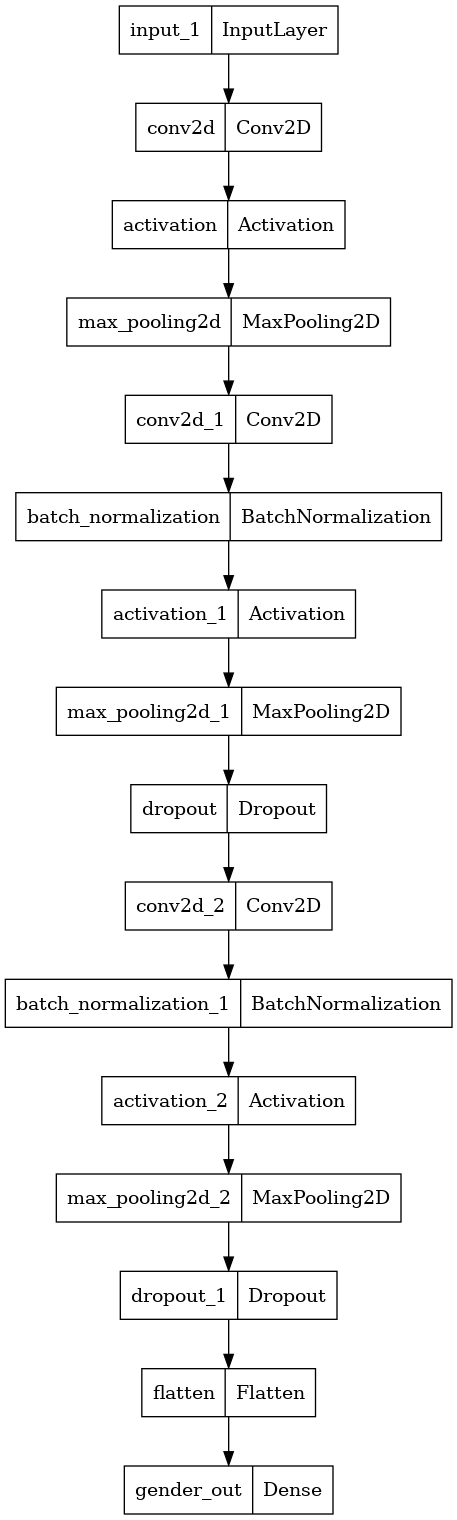

In [11]:
# plot the model
from tensorflow.keras.utils import plot_model
plot_model(model)

In [12]:
# normalizing the images
all_images_pixels = all_images_pixels/255.0

In [13]:
# creating a numpy array, y_gender, containing every image's person gender in the dataframe (0 = Male, 1 = Female)
all_images_genders = npy.array(dfm['gender']) 

In [14]:
# training the model
trained_model = model.fit(x=all_images_pixels, y=all_images_genders, batch_size=32, epochs=15, validation_split=0.12)
model.save('model.keras')
filename = 'finalized_model.sav'
pickle.dump(model, open(filename, 'wb'))

Epoch 1/15
652/652 [==============================] - 556s 850ms/step - loss: 0.4963 - accuracy: 0.7723 - val_loss: 0.3642 - val_accuracy: 0.8538
Epoch 2/15
652/652 [==============================] - 571s 876ms/step - loss: 0.3903 - accuracy: 0.8328 - val_loss: 0.3266 - val_accuracy: 0.8545
Epoch 3/15
652/652 [==============================] - 540s 828ms/step - loss: 0.3537 - accuracy: 0.8462 - val_loss: 0.2889 - val_accuracy: 0.8749
Epoch 4/15
652/652 [==============================] - 537s 823ms/step - loss: 0.3240 - accuracy: 0.8601 - val_loss: 0.2857 - val_accuracy: 0.8847
Epoch 5/15
652/652 [==============================] - 542s 830ms/step - loss: 0.3052 - accuracy: 0.8694 - val_loss: 0.2634 - val_accuracy: 0.8953
Epoch 6/15
652/652 [==============================] - 547s 838ms/step - loss: 0.2892 - accuracy: 0.8786 - val_loss: 0.2561 - val_accuracy: 0.8981
Epoch 7/15
652/652 [==============================] - 547s 838ms/step - loss: 0.2683 - accuracy: 0.8876 - val_loss: 0.2507 -

Gender: Female
1/1 [==============================] - 0s 317ms/step
CNN Model Predicted Gender: Female


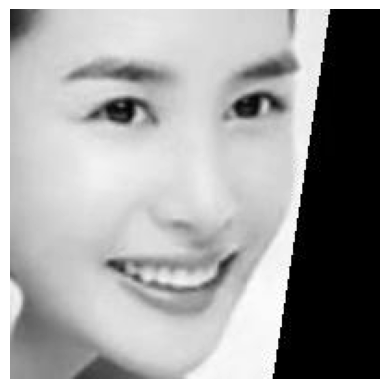

In [15]:
# predicting the images’ person gender
image_index = 492
print("Gender:", gender_dictionary[all_images_genders[image_index]])
predict = model.predict(all_images_pixels[image_index].reshape(1, 200, 200, 1))

predicted_gender = gender_dictionary[round(predict[0][0])]
print("CNN Model Predicted Gender:", predicted_gender)
pplt.axis('off')
pplt.imshow(all_images_pixels[image_index].reshape(200, 200), cmap='gray');

Gender: Female
1/1 [==============================] - 0s 33ms/step
CNN Model Predicted Gender: Female


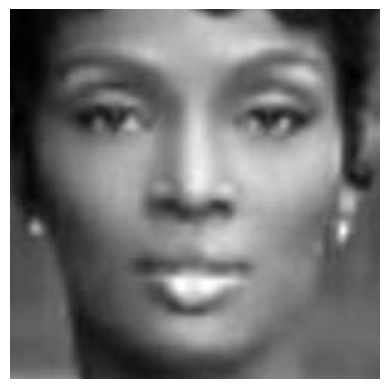

In [16]:
# predicting the images’ person gender
image_index = 1
print("Gender:", gender_dictionary[all_images_genders[image_index]])
predict = model.predict(all_images_pixels[image_index].reshape(1, 200, 200, 1))

predicted_gender = gender_dictionary[round(predict[0][0])]
print("CNN Model Predicted Gender:", predicted_gender)
pplt.axis('off')
pplt.imshow(all_images_pixels[image_index].reshape(200, 200), cmap='gray');

Gender: Male
1/1 [==============================] - 0s 33ms/step
CNN Model Predicted Gender: Male


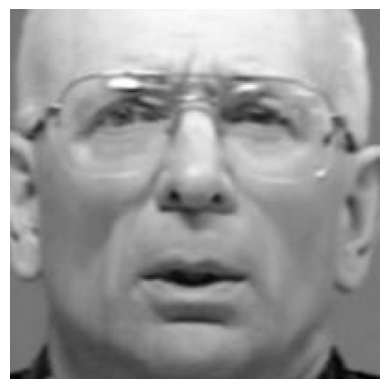

In [17]:
# predicting the images’ person gender
image_index = 25
print("Gender:", gender_dictionary[all_images_genders[image_index]])
predict = model.predict(all_images_pixels[image_index].reshape(1, 200, 200, 1))

predicted_gender = gender_dictionary[round(predict[0][0])]
print("CNN Model Predicted Gender:", predicted_gender)
pplt.axis('off')
pplt.imshow(all_images_pixels[image_index].reshape(200, 200), cmap='gray');

Gender: Female
1/1 [==============================] - 0s 34ms/step
CNN Model Predicted Gender: Female


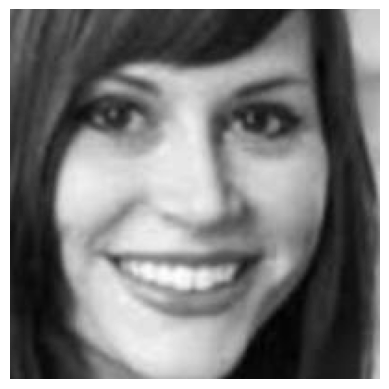

In [18]:
# predicting the images’ person gender
image_index = 90
print("Gender:", gender_dictionary[all_images_genders[image_index]])
predict = model.predict(all_images_pixels[image_index].reshape(1, 200, 200, 1))

predicted_gender = gender_dictionary[round(predict[0][0])]
print("CNN Model Predicted Gender:", predicted_gender)
pplt.axis('off')
pplt.imshow(all_images_pixels[image_index].reshape(200, 200), cmap='gray');

Gender: Female
1/1 [==============================] - 0s 31ms/step
CNN Model Predicted Gender: Female


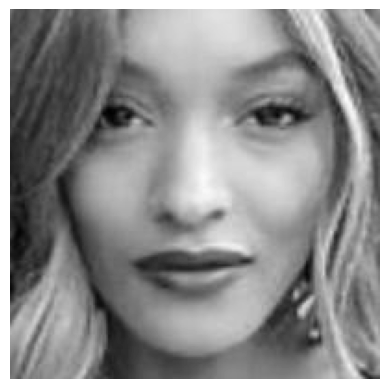

In [19]:
# predicting the images’ person gender
image_index = 108
print("Gender:", gender_dictionary[all_images_genders[image_index]])
predict = model.predict(all_images_pixels[image_index].reshape(1, 200, 200, 1))

predicted_gender = gender_dictionary[round(predict[0][0])]
print("CNN Model Predicted Gender:", predicted_gender)
pplt.axis('off')
pplt.imshow(all_images_pixels[image_index].reshape(200, 200), cmap='gray');